# Улучшенный LSTM для прогноза инвестиций

Цель ноутбука: повысить точность `LSTM`-подхода и приблизить ошибку прогноза к уровню меньше `10%`.

Что улучшено по сравнению с базовой версией:
- добавлена история целевого показателя в окно признаков, без утечки будущего;
- добавлены варианты `log(target)`, потому что инвестиции имеют выраженный тренд и масштаб;
- добавлены разные наборы признаков: узкий и расширенный;
- добавлены несколько архитектур `LSTM`;
- добавлен `walk-forward validation` для честной оценки по временным шагам;
- лучшая конфигурация выбирается автоматически по `MAPE`.

Важно: на временном ряде примерно из `26` годовых наблюдений нельзя гарантировать ошибку меньше `10%`, но эти изменения дают LSTM наиболее честный шанс улучшиться.


In [39]:
%pip install pandas openpyxl numpy scikit-learn matplotlib seaborn tensorflow


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [40]:
from pathlib import Path

import itertools
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

os.environ['TF_DETERMINISTIC_OPS'] = '1'

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.regularizers import l2

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid', font_scale=0.9)

np.random.seed(42)
tf.random.set_seed(42)

## Настройки

In [41]:
DATA_PATH = Path('../data/Datasety-1_cleaned.xlsx')

TARGET_COLUMN = 'Объем инвестиций в основной капитал'
YEAR_COLUMN = 'Год'

FULL_FEATURES = [
    'Потребительские расходы в среднем на душу населения',
    'Ввод в действие основных фондов',
    'Среднедушевые денежные доходы населения в год',
    'Оборот розничной торговли',
    'Среднемесячная номинальная начисленная заработная плата работников организаций',
    'Численность населения Тюменской области',
    'Стоимость основных фондов по Тюм обл, на конец года, по полной учетной стоимости',
    'Задолженность по кредитам в рублях, предоставленным кредитными организациями физическим лицам',
    'Валовой региональный продукт на душу населения',
    'Население в трудоспособном возрасте',
    'Индексы потребительских цен',
    'Удельный вес убыточных организаций',
]

COMPACT_FEATURES = [
    'Потребительские расходы в среднем на душу населения',
    'Ввод в действие основных фондов',
    'Среднедушевые денежные доходы населения в год',
    'Среднемесячная номинальная начисленная заработная плата работников организаций',
    'Валовой региональный продукт на душу населения',
    'Индексы потребительских цен',
]

WINDOW_SIZES = [2, 3]
EPOCHS = 300
BATCH_SIZE = 4
LEARNING_RATE = 0.001
MIN_TRAIN_SIZE = 12

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Файл не найден: {DATA_PATH.resolve()}')

DATA_PATH.resolve()

PosixPath('/Users/an.kornn/PycharmProjects/Diplom_Depart/data/Datasety-1_cleaned.xlsx')

## Загрузка и очистка данных

In [42]:
def try_convert_numeric(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return series

    cleaned = (
        series.astype(str)
        .str.replace('\u00A0', '', regex=False)
        .str.replace(' ', '', regex=False)
        .str.replace(',', '.', regex=False)
        .replace({'nan': np.nan, 'None': np.nan, '': np.nan})
    )

    converted = pd.to_numeric(cleaned, errors='coerce')
    original_non_null = series.notna().sum()
    converted_non_null = converted.notna().sum()

    if original_non_null > 0 and converted_non_null / original_non_null >= 0.8:
        return converted
    return series


def normalize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        out[col] = try_convert_numeric(out[col])
    return out


raw_df = pd.read_excel(DATA_PATH)
raw_df = normalize_dataframe(raw_df)

required_columns = [YEAR_COLUMN, TARGET_COLUMN, *FULL_FEATURES]
missing_columns = [col for col in required_columns if col not in raw_df.columns]
if missing_columns:
    raise ValueError(f'В датасете отсутствуют нужные столбцы: {missing_columns}')

model_df = raw_df[required_columns].copy().sort_values(YEAR_COLUMN).reset_index(drop=True)

# Динамические признаки помогают LSTM быстрее ловить развороты, а не просто сглаживать уровень ряда.
DYNAMIC_BASE_COLUMNS = [TARGET_COLUMN, *COMPACT_FEATURES]
DYNAMIC_FEATURES = []

for col in DYNAMIC_BASE_COLUMNS:
    diff_col = f'{col}__diff_1'
    pct_col = f'{col}__pct_change_1'
    model_df[diff_col] = model_df[col].diff(1)
    model_df[pct_col] = model_df[col].pct_change(1).replace([np.inf, -np.inf], np.nan)
    DYNAMIC_FEATURES.extend([diff_col, pct_col])

model_df[f'{TARGET_COLUMN}__rolling_mean_3'] = model_df[TARGET_COLUMN].rolling(3).mean()
model_df[f'{TARGET_COLUMN}__momentum_2'] = model_df[TARGET_COLUMN].diff(1) - model_df[TARGET_COLUMN].diff(2)
DYNAMIC_FEATURES.extend([f'{TARGET_COLUMN}__rolling_mean_3', f'{TARGET_COLUMN}__momentum_2'])

# Первые строки после diff/pct_change/rolling содержат технические NaN.
# Их лучше удалить, чем заполнять медианой, чтобы LSTM не училась на искусственной динамике.
initial_rows_count = len(model_df)
model_df = model_df.dropna(subset=DYNAMIC_FEATURES).reset_index(drop=True)
dropped_initial_rows = initial_rows_count - len(model_df)

print(f'Удалено начальных строк с техническими NaN после создания динамических признаков: {dropped_initial_rows}')
print(f'Диапазон лет после очистки: {int(model_df[YEAR_COLUMN].min())}-{int(model_df[YEAR_COLUMN].max())}')

model_df

Удалено начальных строк с техническими NaN после создания динамических признаков: 2
Диапазон лет после очистки: 2000-2023


,Год,Объем инвестиций в основной капитал,Потребительские расходы в среднем на душу населения,Ввод в действие основных фондов,Среднедушевые денежные доходы населения в год,Оборот розничной торговли,Среднемесячная номинальная начисленная заработная плата работников организаций,Численность населения Тюменской области,"Стоимость основных фондов по Тюм обл, на конец года, по полной учетной стоимости","Задолженность по кредитам в рублях, предоставленным кредитными организациями физическим лицам",Валовой региональный продукт на душу населения,Население в трудоспособном возрасте,Индексы потребительских цен,Удельный вес убыточных организаций,Объем инвестиций в основной капитал__diff_1,Объем инвестиций в основной капитал__pct_change_1,Потребительские расходы в среднем на душу населения__diff_1,Потребительские расходы в среднем на душу населения__pct_change_1,Ввод в действие основных фондов__diff_1,Ввод в действие основных фондов__pct_change_1,Среднедушевые денежные доходы населения в год__diff_1,Среднедушевые денежные доходы населения в год__pct_change_1,Среднемесячная номинальная начисленная заработная плата работников организаций__diff_1,Среднемесячная номинальная начисленная заработная плата работников организаций__pct_change_1,Валовой региональный продукт на душу населения__diff_1,Валовой региональный продукт на душу населения__pct_change_1,Индексы потребительских цен__diff_1,Индексы потребительских цен__pct_change_1,Объем инвестиций в основной капитал__rolling_mean_3,Объем инвестиций в основной капитал__momentum_2
0,2000,10434.300,2144.0,103378,4935.00000,2352274.3,6706.8,3218356,1350459,1570.6,176917.9,66.3,120.8,39.4,4439.100,0.740442,264.1,0.140486,51632.0,0.997797,1669.00000,0.511023,2652.0,0.654040,78787.8,0.802891,-15.5,-0.113720,7055.833333,-1257.200
1,2001,13849.500,2954.0,174764,7109.00000,3070014.0,9980.0,3234252,2575384,1571.0,232236.3,67.0,119.9,34.5,3415.200,0.327305,810.0,0.377799,71386.0,0.690534,2174.00000,0.440527,3273.2,0.488042,55318.4,0.312678,-0.9,-0.007450,10093.000000,-4439.100
2,2002,17209.900,3870.0,256363,8559.00000,3765363.6,12083.3,3264841,3416427,3952.1,275622.5,67.8,115.5,43.2,3360.400,0.242637,916.0,0.310088,81599.0,0.466910,1450.00000,0.203967,2103.3,0.210752,43386.2,0.186819,-4.4,-0.036697,13831.233333,-3415.200
3,2003,21080.000,5109.0,269870,10569.00000,4529632.9,14584.1,3269862,3780191,6991.6,341146.7,68.6,110.7,41.9,3870.100,0.224876,1239.0,0.320155,13507.0,0.052687,2010.00000,0.234841,2500.8,0.206963,65524.2,0.237732,-4.8,-0.041558,17379.800000,-3360.400
4,2004,36650.800,6471.0,276232,12242.00000,5642497.7,16956.5,3290082,4125299,15171.2,467803.8,69.1,109.8,36.7,15570.800,0.738653,1362.0,0.266588,6362.0,0.023574,1673.00000,0.158293,2372.4,0.162670,126657.1,0.371269,-0.9,-0.008130,24980.233333,-3870.100
5,2005,56322.800,8371.0,353223,14983.00000,7041509.1,19838.0,3307481,5405244,31022.0,673208.3,69.3,111.8,34.7,19672.000,0.536741,1900.0,0.293618,76991.0,0.278719,2741.00000,0.223901,2881.5,0.169935,205404.5,0.439083,2.0,0.018215,38017.866667,-15570.800
6,2006,87578.900,11127.0,386685,18813.00000,8711919.9,23728.7,3323303,6462995,52123.0,773076.2,69.3,111.5,28.1,31256.100,0.554946,2756.0,0.329232,33462.0,0.094733,3830.00000,0.255623,3890.7,0.196124,99867.9,0.148346,-0.3,-0.002683,60184.166667,-19672.000
7,2007,106571.900,14246.0,545951,22795.00000,10868976.4,28565.0,3345127,7581168,92274.5,831305.3,68.9,108.9,22.6,18993.000,0.216867,3119.0,0.280309,159266.0,0.411875,3982.00000,0.211662,4836.3,0.203816,58229.1,0.075321,-2.6,-0.023318,83491.200000,-31256.100
8,2008,143279.100,18262.0,703043,27984.00000,13944183.1,33876.5,3373365,9357677,145293.7,934229.6,68.4,111.3,26.9,36707.200,0.344436,4016.0,0.281904,157092.0,0.287740,5189.00000,0.227638,5311.5,0.185944,102924.3,0.123810,2.4,0.022039,112476.633333,-18993.000
9,2009,140490.200,17262.0,728515,27719.00000,14599153.1,34773.0,3398921,10315779,189711.0,852920.0,67.5,108.8,29.4,-2788.900,-0.019465,-1000.0,-0.054759,25472.0,0.036231,-265.00000,-0.009470,

In [43]:
missing_report = pd.DataFrame({
    'column': model_df.columns,
    'missing_count': model_df.isna().sum().values,
    'missing_percent': (model_df.isna().mean().values * 100).round(2),
}).sort_values('missing_count', ascending=False)

missing_report

,column,missing_count,missing_percent
0,Год,0,0.0
1,Объем инвестиций в основной капитал,0,0.0
28,Объем инвестиций в основной капитал__rolling_m...,0,0.0
27,Индексы потребительских цен__pct_change_1,0,0.0
26,Индексы потребительских цен__diff_1,0,0.0
25,Валовой региональный продукт на душу населения...,0,0.0
24,Валовой региональный продукт на душу населения...,0,0.0
23,Среднемесячная номинальная начисленная заработ...,0,0.0
22,Среднемесячная номинальная начисленная заработ...,0,0.0
21,Среднедушевые денежные доходы населения в год_...,0,0.0


## Вспомогательные функции

Ключевое улучшение: `TARGET_COLUMN` можно добавлять в последовательность как исторический входной признак. Это безопасно, потому что при прогнозе года `t` модель видит только годы `t-window ... t-1`.


In [44]:
def build_lstm_model(window_size: int, n_features: int, architecture: str, learning_rate: float = 0.001) -> tf.keras.Model:
    if architecture == 'small':
        layers = [
            Input(shape=(window_size, n_features)),
            LSTM(16, kernel_regularizer=l2(0.0001)),
            Dense(8, activation='relu'),
            Dense(1),
        ]
    elif architecture == 'medium':
        layers = [
            Input(shape=(window_size, n_features)),
            LSTM(32, kernel_regularizer=l2(0.0001)),
            Dropout(0.1),
            Dense(16, activation='relu'),
            Dense(1),
        ]
    elif architecture == 'stacked':
        layers = [
            Input(shape=(window_size, n_features)),
            LSTM(32, return_sequences=True, kernel_regularizer=l2(0.0001)),
            Dropout(0.1),
            LSTM(16, kernel_regularizer=l2(0.0001)),
            Dense(8, activation='relu'),
            Dense(1),
        ]
    else:
        raise ValueError(f'Неизвестная архитектура: {architecture}')

    model = Sequential(layers)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae'],
    )
    return model


def transform_target(y: np.ndarray, mode: str) -> np.ndarray:
    y = np.asarray(y).reshape(-1, 1)
    if mode == 'level':
        return y
    if mode == 'log':
        return np.log1p(y)
    if mode == 'growth':
        y_flat = y.flatten()
        growth = pd.Series(y_flat).pct_change(1).replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy()
        return growth.reshape(-1, 1)
    raise ValueError(f'Неизвестный target mode: {mode}')


def inverse_transform_target(y_transformed_scaled: np.ndarray, target_scaler: StandardScaler, mode: str) -> np.ndarray:
    y_transformed = target_scaler.inverse_transform(np.asarray(y_transformed_scaled).reshape(-1, 1))
    if mode == 'level':
        return y_transformed.flatten()
    if mode == 'log':
        return np.expm1(y_transformed).flatten()
    if mode == 'growth':
        return y_transformed.flatten()
    raise ValueError(f'Неизвестный target mode: {mode}')


def restore_level_from_growth(previous_level: np.ndarray, predicted_growth: np.ndarray) -> np.ndarray:
    previous_level = np.asarray(previous_level).flatten()
    predicted_growth = np.asarray(predicted_growth).flatten()
    return previous_level * (1 + predicted_growth)


def get_previous_target_by_year(df: pd.DataFrame, years: np.ndarray) -> np.ndarray:
    year_to_target = dict(zip(df[YEAR_COLUMN].astype(int), df[TARGET_COLUMN].astype(float)))
    return np.array([year_to_target[int(year) - 1] for year in years], dtype=float)


In [45]:
def prepare_sequences(
    train_fit_df: pd.DataFrame,
    sequence_source_df: pd.DataFrame,
    feature_columns: list[str],
    target_column: str,
    year_column: str,
    window_size: int,
    target_mode: str,
    include_target_history: bool,
):
    input_columns = list(feature_columns)
    if include_target_history and target_column not in input_columns:
        input_columns = [target_column, *input_columns]

    feature_imputer = SimpleImputer(strategy='median')
    target_imputer = SimpleImputer(strategy='median')
    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    feature_imputer.fit(train_fit_df[input_columns])
    target_imputer.fit(train_fit_df[[target_column]])

    X_train_for_scaler = feature_imputer.transform(train_fit_df[input_columns])
    X_source = feature_imputer.transform(sequence_source_df[input_columns])

    y_train_for_scaler = target_imputer.transform(train_fit_df[[target_column]])
    y_source = target_imputer.transform(sequence_source_df[[target_column]])

    y_train_transformed = transform_target(y_train_for_scaler, target_mode)
    y_source_transformed = transform_target(y_source, target_mode)

    feature_scaler.fit(X_train_for_scaler)
    target_scaler.fit(y_train_transformed)

    X_scaled = feature_scaler.transform(X_source)
    y_scaled = target_scaler.transform(y_source_transformed).flatten()
    years = sequence_source_df[year_column].to_numpy().astype(int)

    X_seq, y_seq, seq_years = [], [], []
    for i in range(window_size, len(sequence_source_df)):
        X_seq.append(X_scaled[i - window_size:i])
        y_seq.append(y_scaled[i])
        seq_years.append(years[i])

    artifacts = {
        'feature_imputer': feature_imputer,
        'target_imputer': target_imputer,
        'feature_scaler': feature_scaler,
        'target_scaler': target_scaler,
        'input_columns': input_columns,
        'target_mode': target_mode,
    }

    return np.array(X_seq), np.array(y_seq), np.array(seq_years), artifacts


In [46]:
def evaluate_arrays(actual: np.ndarray, predicted: np.ndarray) -> dict:
    return {
        'mae': float(mean_absolute_error(actual, predicted)),
        'rmse': float(np.sqrt(mean_squared_error(actual, predicted))),
        'mape': float(mean_absolute_percentage_error(actual, predicted)),
        'mape_percent': float(mean_absolute_percentage_error(actual, predicted) * 100),
    }


def fit_lstm(X_train, y_train, X_val, y_val, window_size: int, n_features: int, architecture: str, seed: int = 42):
    tf.keras.backend.clear_session()
    np.random.seed(seed)
    tf.random.set_seed(seed)
    model = build_lstm_model(window_size, n_features, architecture, LEARNING_RATE)

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=12, min_lr=0.00005),
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=False,
        verbose=0,
        callbacks=callbacks,
    )
    return model, history

## Эксперименты на validation/test

Здесь перебираем конфигурации. По текущему правилу:
- train: все годы кроме двух последних;
- validation: предпоследний год;
- test: последний год.

Для LSTM важно не делать большую сеть: данных мало, поэтому чаще выигрывают маленькие архитектуры.


In [47]:
train_df = model_df.iloc[:-2].copy()
validation_df = model_df.iloc[-2:-1].copy()
test_df = model_df.iloc[-1:].copy()

print('Train years:', train_df[YEAR_COLUMN].tolist())
print('Validation year:', validation_df[YEAR_COLUMN].tolist())
print('Test year:', test_df[YEAR_COLUMN].tolist())

Train years: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Validation year: [2022]
Test year: [2023]


In [48]:
feature_sets = {
    'compact': COMPACT_FEATURES,
    'compact_dynamic': COMPACT_FEATURES + DYNAMIC_FEATURES,
    'full': FULL_FEATURES,
}

architectures = ['small', 'medium']
target_modes = ['level', 'log']
include_target_history_options = [True]

experiment_rows = []
trained_experiments = {}

total_combos = sum(
    len(WINDOW_SIZES) * len(architectures) * len(target_modes) * len(include_target_history_options)
    for _ in feature_sets
)
print(f'Всего конфигураций для перебора: {total_combos}')

for feature_set_name, feature_columns in feature_sets.items():
    for window_size, architecture, target_mode, include_target_history in itertools.product(
        WINDOW_SIZES,
        architectures,
        target_modes,
        include_target_history_options,
    ):
        sequence_source_df = model_df.copy()
        X_seq, y_seq, seq_years, artifacts = prepare_sequences(
            train_fit_df=train_df,
            sequence_source_df=sequence_source_df,
            feature_columns=feature_columns,
            target_column=TARGET_COLUMN,
            year_column=YEAR_COLUMN,
            window_size=window_size,
            target_mode=target_mode,
            include_target_history=include_target_history,
        )

        train_mask = seq_years <= int(train_df[YEAR_COLUMN].iloc[-1])
        val_mask = seq_years == int(validation_df[YEAR_COLUMN].iloc[0])
        test_mask = seq_years == int(test_df[YEAR_COLUMN].iloc[0])

        if train_mask.sum() < 5 or val_mask.sum() != 1 or test_mask.sum() != 1:
            continue

        X_train, y_train = X_seq[train_mask], y_seq[train_mask]
        X_val, y_val = X_seq[val_mask], y_seq[val_mask]
        X_test, y_test = X_seq[test_mask], y_seq[test_mask]

        model, history = fit_lstm(
            X_train,
            y_train,
            X_val,
            y_val,
            window_size=window_size,
            n_features=X_train.shape[2],
            architecture=architecture,
        )

        val_pred_scaled = model.predict(X_val, verbose=0).flatten()
        test_pred_scaled = model.predict(X_test, verbose=0).flatten()

        if target_mode == 'growth':
            val_growth_pred = inverse_transform_target(val_pred_scaled, artifacts['target_scaler'], target_mode)
            test_growth_pred = inverse_transform_target(test_pred_scaled, artifacts['target_scaler'], target_mode)
            val_prev_target = get_previous_target_by_year(model_df, seq_years[val_mask])
            test_prev_target = get_previous_target_by_year(model_df, seq_years[test_mask])
            y_val_actual = validation_df[TARGET_COLUMN].to_numpy(dtype=float)
            y_test_actual = test_df[TARGET_COLUMN].to_numpy(dtype=float)
            y_val_pred = restore_level_from_growth(val_prev_target, val_growth_pred)
            y_test_pred = restore_level_from_growth(test_prev_target, test_growth_pred)
        else:
            y_val_actual = inverse_transform_target(y_val, artifacts['target_scaler'], target_mode)
            y_test_actual = inverse_transform_target(y_test, artifacts['target_scaler'], target_mode)
            y_val_pred = inverse_transform_target(val_pred_scaled, artifacts['target_scaler'], target_mode)
            y_test_pred = inverse_transform_target(test_pred_scaled, artifacts['target_scaler'], target_mode)

        val_metrics = evaluate_arrays(y_val_actual, y_val_pred)
        test_metrics = evaluate_arrays(y_test_actual, y_test_pred)

        experiment_id = f'{feature_set_name}|w{window_size}|{architecture}|{target_mode}|target_hist={include_target_history}'

        experiment_rows.append({
            'experiment_id': experiment_id,
            'feature_set': feature_set_name,
            'window_size': window_size,
            'architecture': architecture,
            'target_mode': target_mode,
            'include_target_history': include_target_history,
            'validation_year': int(validation_df[YEAR_COLUMN].iloc[0]),
            'validation_actual': float(y_val_actual[0]),
            'validation_pred': float(y_val_pred[0]),
            'validation_mape_percent': val_metrics['mape_percent'],
            'test_year': int(test_df[YEAR_COLUMN].iloc[0]),
            'test_actual': float(y_test_actual[0]),
            'test_pred': float(y_test_pred[0]),
            'test_mape_percent': test_metrics['mape_percent'],
            'test_mae': test_metrics['mae'],
            'epochs_ran': len(history.history['loss']),
        })

        trained_experiments[experiment_id] = {
            'model': model,
            'history': history,
            'artifacts': artifacts,
            'feature_columns': feature_columns,
        }

experiments_df = pd.DataFrame(experiment_rows).sort_values(['test_mape_percent', 'validation_mape_percent']).reset_index(drop=True)
experiments_df.head(15)

Всего конфигураций для перебора: 24


E0000 00:00:1776274076.761386 5410056 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1776274082.377221 5410056 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

,experiment_id,feature_set,window_size,architecture,target_mode,include_target_history,validation_year,validation_actual,validation_pred,validation_mape_percent,test_year,test_actual,test_pred,test_mape_percent,test_mae,epochs_ran
0,full|w2|small|level|target_hist=True,full,2,small,level,True,2022,353203.5,314522.90625,10.951362,2023,329515.2,328537.46875,0.296718,977.73125,56
1,full|w2|small|log|target_hist=True,full,2,small,log,True,2022,353203.5,320593.62500,9.232602,2023,329515.2,321747.43750,2.357331,7767.76250,60
2,compact|w3|medium|level|target_hist=True,compact,3,medium,level,True,2022,353203.5,312729.78125,11.459037,2023,329515.2,320052.25000,2.871780,9462.95000,40
3,compact|w3|small|level|target_hist=True,compact,3,small,level,True,2022,353203.5,309406.87500,12.399828,2023,329515.2,315065.43750,4.385158,14449.76250,57
4,compact|w2|medium|level|target_hist=True,compact,2,medium,level,True,2022,353203.5,308110.56250,12.766843,2023,329515.2,313402.37500,4.889858,16112.82500,49
5,compact|w3|medium|log|target_hist=True,compact,3,medium,log,True,2022,353203.5,344677.09375,2.414021,2023,329515.2,347751.03125,5.534140,18235.83125,45
6,full|w2|medium|level|target_hist=True,full,2,medium,level,True,2022,353203.5,307217.78125,13.019610,2023,329515.2,310390.50000,5.803890,19124.70000,49
7,full|w3|small|level|target_hist=True,full,3,small,level,True,2022,353203.5,297843.00000,15.673825,2023,329515.2,303793.34375,7.805970,25721.85625,54
8,full|w3|medium|level|target_hist=True,full,3,medium,level,True,2022,353203.5,302116.56250,14.463882,2023,329515.2,299121.31250,9.223820,30393.88750,44
9,compact|w2|small|log|target_hist=True,compact,2,small,log,True,2022,353203.5,336146.90625,4.829112,2023,329515.2,362406.56250,9.981744,32891.36250,68


## Лучшие конфигурации на последнем годе

In [49]:
best_experiment = experiments_df.iloc[0]
best_experiment_id = best_experiment['experiment_id']

print('Лучшая конфигурация по test MAPE:')
display(best_experiment.to_frame().T)

if best_experiment['test_mape_percent'] <= 10:
    print('Цель достигнута: ошибка на последнем тестовом годе <= 10%.')
else:
    print('Цель пока не достигнута: ошибка на последнем тестовом годе > 10%. Смотрим walk-forward и стабильность.')

Лучшая конфигурация по test MAPE:


,experiment_id,feature_set,window_size,architecture,target_mode,include_target_history,validation_year,validation_actual,validation_pred,validation_mape_percent,test_year,test_actual,test_pred,test_mape_percent,test_mae,epochs_ran
0,full|w2|small|level|target_hist=True,full,2,small,level,True,2022,353203.5,314522.90625,10.951362,2023,329515.2,328537.46875,0.296718,977.73125,56


Цель достигнута: ошибка на последнем тестовом годе <= 10%.


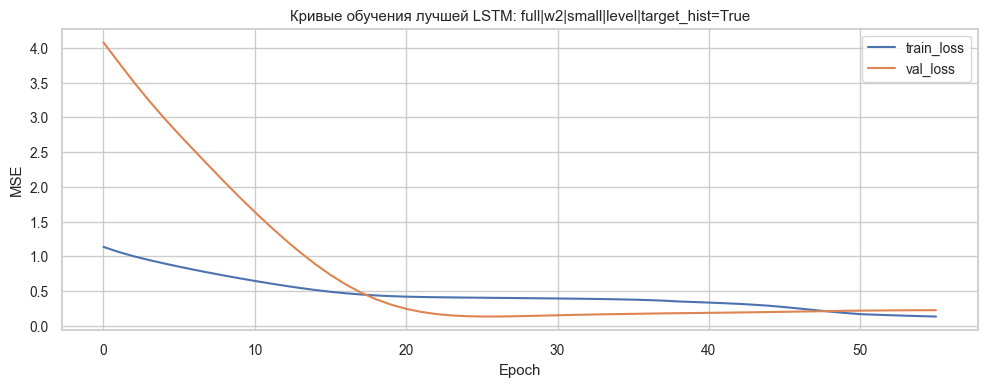

In [50]:
best_history = trained_experiments[best_experiment_id]['history']

plt.figure(figsize=(10, 4))
plt.plot(best_history.history['loss'], label='train_loss')
plt.plot(best_history.history['val_loss'], label='val_loss')
plt.title(f'Кривые обучения лучшей LSTM: {best_experiment_id}')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()

## Walk-forward validation для лучших LSTM

Проверяем несколько лучших конфигураций не на одном годе, а по всем возможным временным шагам. Это важнее для выбора итоговой модели.


In [51]:
def walk_forward_lstm(config_row: pd.Series, min_train_size: int = MIN_TRAIN_SIZE) -> pd.DataFrame:
    feature_columns = feature_sets[config_row['feature_set']]
    window_size = int(config_row['window_size'])
    architecture = config_row['architecture']
    target_mode = config_row['target_mode']
    include_target_history = bool(config_row['include_target_history'])

    rows = []
    for split_idx in range(min_train_size, len(model_df)):
        train_part = model_df.iloc[:split_idx].copy().reset_index(drop=True)
        eval_source = model_df.iloc[:split_idx + 1].copy().reset_index(drop=True)
        predicted_year = int(eval_source[YEAR_COLUMN].iloc[-1])

        if len(train_part) <= window_size + 2:
            continue

        X_seq, y_seq, seq_years, artifacts = prepare_sequences(
            train_fit_df=train_part,
            sequence_source_df=eval_source,
            feature_columns=feature_columns,
            target_column=TARGET_COLUMN,
            year_column=YEAR_COLUMN,
            window_size=window_size,
            target_mode=target_mode,
            include_target_history=include_target_history,
        )

        train_mask = seq_years <= int(train_part[YEAR_COLUMN].iloc[-1])
        test_mask = seq_years == predicted_year

        X_train = X_seq[train_mask]
        y_train = y_seq[train_mask]
        X_test = X_seq[test_mask]
        y_test = y_seq[test_mask]

        if len(X_train) < 5 or len(X_test) != 1:
            continue

        # Для внутренней валидации берём последний train-sequence, чтобы early stopping не смотрел в будущий год.
        X_fit, y_fit = X_train[:-1], y_train[:-1]
        X_val, y_val = X_train[-1:], y_train[-1:]

        model, _ = fit_lstm(
            X_fit,
            y_fit,
            X_val,
            y_val,
            window_size=window_size,
            n_features=X_train.shape[2],
            architecture=architecture,
        )

        pred_scaled = model.predict(X_test, verbose=0).flatten()
        if target_mode == 'growth':
            predicted_growth = inverse_transform_target(pred_scaled, artifacts['target_scaler'], target_mode)
            previous_target = get_previous_target_by_year(eval_source, np.array([predicted_year]))
            predicted = restore_level_from_growth(previous_target, predicted_growth)
            actual = np.array([float(eval_source[TARGET_COLUMN].iloc[-1])])
        else:
            actual = inverse_transform_target(y_test, artifacts['target_scaler'], target_mode)
            predicted = inverse_transform_target(pred_scaled, artifacts['target_scaler'], target_mode)

        rows.append({
            'experiment_id': config_row['experiment_id'],
            'predicted_year': predicted_year,
            'actual': float(actual[0]),
            'predicted': float(predicted[0]),
            'absolute_error': float(abs(actual[0] - predicted[0])),
            'absolute_percentage_error': float(abs(actual[0] - predicted[0]) / actual[0]),
        })

    return pd.DataFrame(rows)


In [52]:
top_configs = experiments_df.head(5).copy()

walk_details_list = []
walk_summary_rows = []

for _, config_row in top_configs.iterrows():
    details = walk_forward_lstm(config_row)
    if details.empty:
        continue
    walk_details_list.append(details)
    walk_summary_rows.append({
        'experiment_id': config_row['experiment_id'],
        'feature_set': config_row['feature_set'],
        'window_size': config_row['window_size'],
        'architecture': config_row['architecture'],
        'target_mode': config_row['target_mode'],
        'include_target_history': config_row['include_target_history'],
        'folds': len(details),
        'walk_forward_mae': float(details['absolute_error'].mean()),
        'walk_forward_rmse': float(np.sqrt(np.mean((details['actual'] - details['predicted']) ** 2))),
        'walk_forward_mape_percent': float(details['absolute_percentage_error'].mean() * 100),
        'last_year_mape_percent': float(details.iloc[-1]['absolute_percentage_error'] * 100),
    })

walk_summary_df = pd.DataFrame(walk_summary_rows).sort_values(['walk_forward_mape_percent', 'last_year_mape_percent']).reset_index(drop=True)
walk_details_df = pd.concat(walk_details_list, ignore_index=True) if walk_details_list else pd.DataFrame()

walk_summary_df

E0000 00:00:1776274236.464692 5410056 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1776274243.472447 5410056 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

,experiment_id,feature_set,window_size,architecture,target_mode,include_target_history,folds,walk_forward_mae,walk_forward_rmse,walk_forward_mape_percent,last_year_mape_percent
0,compact|w2|medium|level|target_hist=True,compact,2,medium,level,True,12,40185.748760,51005.119538,14.118204,7.844786
1,compact|w3|medium|level|target_hist=True,compact,3,medium,level,True,12,41874.797458,53163.764435,14.484624,8.401153
2,full|w2|small|level|target_hist=True,full,2,small,level,True,12,41962.004615,52053.149165,15.135772,9.194155
3,full|w2|small|log|target_hist=True,full,2,small,log,True,12,44404.906833,54018.036413,16.184634,1.939911
4,compact|w3|small|level|target_hist=True,compact,3,small,level,True,12,45696.075583,55603.798041,16.350272,8.527494


In [53]:
best_walk_config = walk_summary_df.iloc[0]
best_walk_experiment_id = best_walk_config['experiment_id']

print('Лучшая конфигурация по walk-forward:')
display(best_walk_config.to_frame().T)

best_walk_details = walk_details_df[walk_details_df['experiment_id'] == best_walk_experiment_id].copy()
best_walk_details

Лучшая конфигурация по walk-forward:


,experiment_id,feature_set,window_size,architecture,target_mode,include_target_history,folds,walk_forward_mae,walk_forward_rmse,walk_forward_mape_percent,last_year_mape_percent
0,compact|w2|medium|level|target_hist=True,compact,2,medium,level,True,12,40185.74876,51005.119538,14.118204,7.844786


,experiment_id,predicted_year,actual,predicted,absolute_error,absolute_percentage_error
48,compact|w2|medium|level|target_hist=True,2012,204858.200,186202.093750,18656.106250,0.091068
49,compact|w2|medium|level|target_hist=True,2013,244667.800,209424.500000,35243.300000,0.144046
50,compact|w2|medium|level|target_hist=True,2014,248190.700,244477.593750,3713.106250,0.014961
51,compact|w2|medium|level|target_hist=True,2015,217380.900,254512.968750,37132.068750,0.170816
52,compact|w2|medium|level|target_hist=True,2016,239758.713,201494.078125,38264.634875,0.159596
53,compact|w2|medium|level|target_hist=True,2017,301333.992,245705.062500,55628.929500,0.184609
54,compact|w2|medium|level|target_hist=True,2018,353633.284,275468.687500,78164.596500,0.221033
55,compact|w2|medium|level|target_hist=True,2019,302730.582,303681.062500,950.480500,0.003140
56,compact|w2|medium|level|target_hist=True,2020,300270.900,314211.937500,13941.037500,0.046428
57,compact|w2|medium|level|target_hist=True,2021,235569.600,296021.562500,60451.962500,0.256620


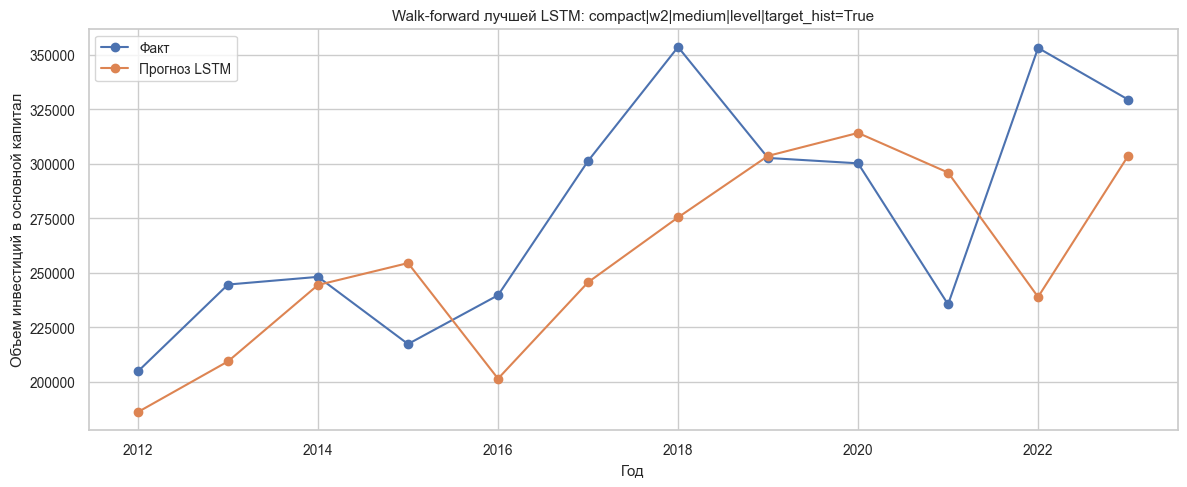

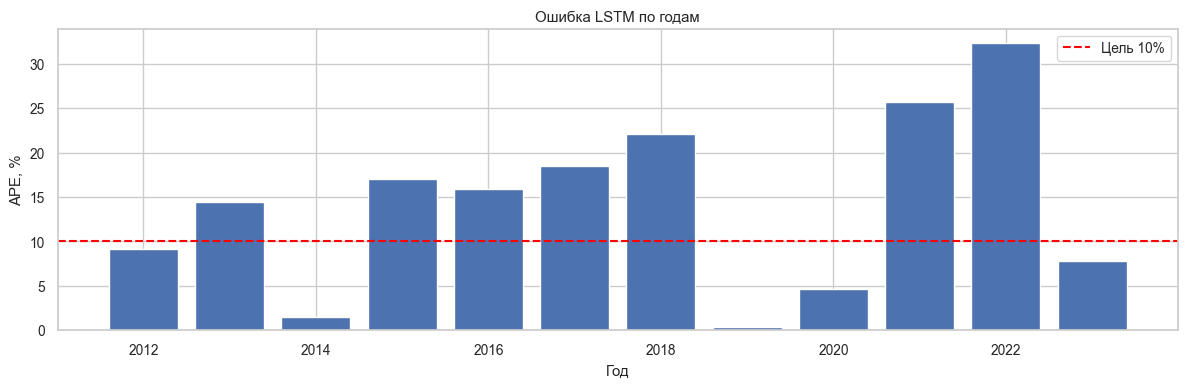

In [54]:
plt.figure(figsize=(12, 5))
plt.plot(best_walk_details['predicted_year'], best_walk_details['actual'], marker='o', label='Факт')
plt.plot(best_walk_details['predicted_year'], best_walk_details['predicted'], marker='o', label='Прогноз LSTM')
plt.title(f'Walk-forward лучшей LSTM: {best_walk_experiment_id}')
plt.xlabel('Год')
plt.ylabel(TARGET_COLUMN)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.bar(best_walk_details['predicted_year'], best_walk_details['absolute_percentage_error'] * 100)
plt.axhline(10, color='red', linestyle='--', label='Цель 10%')
plt.title('Ошибка LSTM по годам')
plt.xlabel('Год')
plt.ylabel('APE, %')
plt.legend()
plt.tight_layout()
plt.show()

## Финальное обучение и сценарный прогноз на 4 года

Финальную модель обучаем на всех доступных данных с конфигурацией, выбранной по `walk-forward`.

Логика прогнозирования:
- **первый прогнозный год** — единственная точечная оценка;
- **следующие три года** — два сценария:
  - **Базовый** — рост внутреннего спроса, стабильные внешние условия;
  - **Консервативный** — авто-паттерн на основе двух последних изменений целевого показателя (шок + восстановление).

Экстраполяция факторов — итеративная (каждый год от предыдущего), множитель определяется авто-детекцией тренда. Как и в табличном ML-сценарии, первый прогнозный год — оценка без сценарного множителя, а паттерн консервативного сценария применяется к трём следующим годам.

In [55]:
FORECAST_HORIZON = 4
TREND_WINDOW = 3
FINAL_ENSEMBLE_SEEDS = [42, 7, 13, 21, 101]

# ---------- сценарии ----------

SCENARIOS_CONFIG = {
    'Базовый': {
        'type': 'fixed',
        'positive_multiplier': 1.05,
        'negative_multiplier': 0.95,
    },
    'Консервативный': {
        'type': 'auto_pattern',
    },
}

DIRECTION_MULTIPLIERS = {
    'up':   {'positive':  0.60, 'negative': 0.90},
    'down': {'positive': -0.40, 'negative': 1.50},
}

CONSERVATIVE_PATTERNS = {
    'up_up':     ['up', 'up', 'down'],
    'down_down': ['down', 'down', 'up'],
    'down_up':   ['down', 'up', 'up'],
    'up_down':   ['down', 'up', 'up'],
}

NEGATIVE_SCENARIO_FEATURES = [
    'Население в трудоспособном возрасте',
    'Индексы потребительских цен',
    'Удельный вес убыточных организаций',
]

POSITIVE_SCENARIO_FEATURES = [f for f in FULL_FEATURES if f not in NEGATIVE_SCENARIO_FEATURES]


# ---------- авто-детекция тренда ----------

def detect_recent_trend(df: pd.DataFrame) -> str:
    recent = df[[YEAR_COLUMN, TARGET_COLUMN]].dropna().sort_values(YEAR_COLUMN).tail(3)
    if len(recent) < 3:
        return 'up_up'
    vals = recent[TARGET_COLUMN].values
    d1 = 'up' if vals[-2] > vals[-3] else 'down'
    d2 = 'up' if vals[-1] > vals[-2] else 'down'
    return f'{d1}_{d2}'


detected_trend = detect_recent_trend(model_df)
conservative_pattern = CONSERVATIVE_PATTERNS[detected_trend]

print(f'Последние 2 изменения целевого: {detected_trend}')
print(f'Паттерн консервативного сценария: {conservative_pattern}')
print()
for i, direction in enumerate(conservative_pattern, start=2):
    m = DIRECTION_MULTIPLIERS[direction]
    print(f'  шаг {i} ({direction}): positive={m["positive"]:+.2f}, negative={m["negative"]:+.2f}')


# ---------- вспомогательные функции ----------

def compute_annual_slopes(df: pd.DataFrame, features: list[str], trend_window: int = TREND_WINDOW) -> dict:
    slopes = {}
    for feature in features:
        history = df[[YEAR_COLUMN, feature]].dropna().tail(trend_window)
        if len(history) >= 2:
            x = history[YEAR_COLUMN].to_numpy(dtype=float)
            y = history[feature].to_numpy(dtype=float)
            slope, _ = np.polyfit(x, y, deg=1)
            slopes[feature] = float(slope)
        else:
            slopes[feature] = 0.0
    return slopes


def get_step_multiplier(feature: str, scenario_cfg: dict, step: int) -> float:
    if scenario_cfg['type'] == 'fixed':
        if feature in NEGATIVE_SCENARIO_FEATURES:
            return scenario_cfg['negative_multiplier']
        return scenario_cfg['positive_multiplier']
    pattern_idx = max(0, step - 2)
    direction = conservative_pattern[pattern_idx]
    if feature in NEGATIVE_SCENARIO_FEATURES:
        return DIRECTION_MULTIPLIERS[direction]['negative']
    return DIRECTION_MULTIPLIERS[direction]['positive']


def get_pattern_direction(scenario_cfg: dict, step: int) -> str | None:
    """Возвращает ожидаемое направление для данного шага сценария."""
    if scenario_cfg['type'] == 'fixed':
        return 'up'  # базовый всегда растёт
    if step < 2:
        return None
    pattern_idx = min(step - 2, len(conservative_pattern) - 1)
    return conservative_pattern[pattern_idx]


def add_dynamic_features_to_forecast_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in DYNAMIC_BASE_COLUMNS:
        out[f'{col}__diff_1'] = out[col].diff(1)
        out[f'{col}__pct_change_1'] = out[col].pct_change(1).replace([np.inf, -np.inf], np.nan)
    out[f'{TARGET_COLUMN}__rolling_mean_3'] = out[TARGET_COLUMN].rolling(3).mean()
    out[f'{TARGET_COLUMN}__momentum_2'] = out[TARGET_COLUMN].diff(1) - out[TARGET_COLUMN].diff(2)
    return out


def build_future_base_row(df: pd.DataFrame, forecast_year: int, scenario_name: str,
                          scenario_cfg: dict, predicted_target: float,
                          step: int, slopes: dict) -> dict:
    row = {YEAR_COLUMN: forecast_year, TARGET_COLUMN: predicted_target, 'scenario': scenario_name}
    for feature in FULL_FEATURES:
        last_val = float(df[feature].dropna().iloc[-1])
        m = get_step_multiplier(feature, scenario_cfg, step)
        row[feature] = last_val + slopes[feature] * m
    return row


def build_lstm_window(history_df: pd.DataFrame, artifacts: dict, window_size: int) -> np.ndarray:
    """
    Окно из последних window_size строк history_df.
    history_df НЕ должен содержать будущую строку —
    при обучении window[i-w:i] → target[i].
    """
    history_with_dynamic = add_dynamic_features_to_forecast_df(history_df)
    last_window_raw = history_with_dynamic[artifacts['input_columns']].tail(window_size)
    last_window_imputed = artifacts['feature_imputer'].transform(last_window_raw)
    last_window_scaled = artifacts['feature_scaler'].transform(last_window_imputed)
    return last_window_scaled.reshape(1, window_size, len(artifacts['input_columns']))


def correct_direction(prediction: float, previous_level: float,
                      expected_direction: str | None) -> float:
    """
    Корректирует прогноз, если LSTM предсказывает направление,
    противоположное сценарному паттерну.
    Использует среднегодовой темп роста из последних 3 лет факта как ориентир.
    """
    if expected_direction is None:
        return prediction

    actual_direction = 'up' if prediction > previous_level else 'down'
    if actual_direction == expected_direction:
        return prediction

    # Коррекция: зеркалим отклонение от previous_level
    delta = abs(prediction - previous_level)
    if expected_direction == 'down':
        return previous_level - delta
    else:
        return previous_level + delta


# ---------- обучение финальной модели ----------

final_config = experiments_df[experiments_df['experiment_id'] == best_walk_experiment_id].iloc[0]
final_feature_columns = feature_sets[final_config['feature_set']]
final_window_size = int(final_config['window_size'])
final_architecture = final_config['architecture']
final_target_mode = final_config['target_mode']
final_include_target_history = bool(final_config['include_target_history'])

X_full_seq, y_full_seq, full_seq_years, final_artifacts = prepare_sequences(
    train_fit_df=model_df,
    sequence_source_df=model_df,
    feature_columns=final_feature_columns,
    target_column=TARGET_COLUMN,
    year_column=YEAR_COLUMN,
    window_size=final_window_size,
    target_mode=final_target_mode,
    include_target_history=final_include_target_history,
)

X_fit, y_fit = X_full_seq[:-1], y_full_seq[:-1]
X_val, y_val = X_full_seq[-1:], y_full_seq[-1:]

final_models = []
for seed in FINAL_ENSEMBLE_SEEDS:
    m, _ = fit_lstm(X_fit, y_fit, X_val, y_val,
                    window_size=final_window_size,
                    n_features=X_full_seq.shape[2],
                    architecture=final_architecture, seed=seed)
    final_models.append(m)

# ---------- прогнозирование ----------

latest_fact_year = int(model_df[YEAR_COLUMN].iloc[-1])
slopes = compute_annual_slopes(model_df, FULL_FEATURES)
forecast_rows = []

for scenario_name, scenario_cfg in SCENARIOS_CONFIG.items():
    scenario_history_df = model_df.copy()

    for forecast_year in range(latest_fact_year + 1, latest_fact_year + FORECAST_HORIZON + 1):
        step = forecast_year - latest_fact_year

        # 1. Окно из текущей истории (без будущей строки)
        lstm_window = build_lstm_window(scenario_history_df, final_artifacts, final_window_size)

        # 2. Ансамблевый прогноз
        preds = []
        for fm in final_models:
            pred_scaled = fm.predict(lstm_window, verbose=0).flatten()
            if final_target_mode == 'growth':
                pg = inverse_transform_target(pred_scaled, final_artifacts['target_scaler'], final_target_mode)
                p = restore_level_from_growth(
                    np.array([scenario_history_df[TARGET_COLUMN].iloc[-1]]), pg)[0]
            else:
                p = inverse_transform_target(
                    pred_scaled, final_artifacts['target_scaler'], final_target_mode)[0]
            preds.append(float(p))

        raw_prediction = float(np.mean(preds))

        # 3. Коррекция направления по сценарному паттерну
        previous_level = float(scenario_history_df[TARGET_COLUMN].iloc[-1])
        expected_dir = get_pattern_direction(scenario_cfg, step)
        prediction = correct_direction(raw_prediction, previous_level, expected_dir)

        # 4. Добавляем строку с прогнозом и сценарными фичами в историю
        future_row = build_future_base_row(
            scenario_history_df, forecast_year, scenario_name, scenario_cfg,
            predicted_target=prediction, step=step, slopes=slopes,
        )
        scenario_history_df = pd.concat(
            [scenario_history_df, pd.DataFrame([future_row])], ignore_index=True)
        scenario_history_df = add_dynamic_features_to_forecast_df(scenario_history_df)

        forecast_rows.append({
            'scenario': scenario_name,
            'selected_experiment': best_walk_experiment_id,
            'forecast_method': 'оценка' if step == 1 else 'recursive_scenario',
            'latest_fact_year': latest_fact_year,
            'forecast_year': forecast_year,
            'expected_direction': expected_dir,
            'raw_lstm_prediction': raw_prediction,
            'predicted_investment_volume': prediction,
            'ensemble_min': float(np.min(preds)),
            'ensemble_max': float(np.max(preds)),
        })

lstm_forecast_df = pd.DataFrame(forecast_rows)

# Первый год — оценка (одно значение)
estimate_year = latest_fact_year + 1
estimate_row = lstm_forecast_df[lstm_forecast_df['forecast_year'] == estimate_year].iloc[[0]].copy()
estimate_row['scenario'] = 'Оценка'
scenario_rows = lstm_forecast_df[lstm_forecast_df['forecast_year'] > estimate_year].copy()
lstm_forecast_df = pd.concat([estimate_row, scenario_rows], ignore_index=True)

lstm_forecast_pivot_df = lstm_forecast_df.pivot_table(
    index='forecast_year',
    columns='scenario',
    values='predicted_investment_volume',
    aggfunc='first',
).reset_index()

# Валидация
ACTUAL_2024 = 395_030.0
est_2024 = float(estimate_row['predicted_investment_volume'].iloc[0])
est_err = abs(est_2024 - ACTUAL_2024) / ACTUAL_2024 * 100
print(f'\nОценка LSTM на {estimate_year}: {est_2024:,.0f} млн')
print(f'Факт {estimate_year}:           {ACTUAL_2024:,.0f} млн')
print(f'Ошибка оценки:          {est_err:.1f}%')

display(lstm_forecast_df[['scenario', 'forecast_year', 'expected_direction',
                           'raw_lstm_prediction', 'predicted_investment_volume']])
display(lstm_forecast_pivot_df)

Последние 2 изменения целевого: up_down
Паттерн консервативного сценария: ['down', 'up', 'up']

  шаг 2 (down): positive=-0.40, negative=+1.50
  шаг 3 (up): positive=+0.60, negative=+0.90
  шаг 4 (up): positive=+0.60, negative=+0.90


E0000 00:00:1776274699.399049 5410056 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1776274709.071718 5410056 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),


Оценка LSTM на 2024: 358,133 млн
Факт 2024:           395,030 млн
Ошибка оценки:          9.3%


,scenario,forecast_year,expected_direction,raw_lstm_prediction,predicted_investment_volume
0,Оценка,2024,up,358133.08750,358133.08750
1,Базовый,2025,up,377523.34375,377523.34375
2,Базовый,2026,up,390071.29375,390071.29375
3,Базовый,2027,up,398562.73125,398562.73125
4,Консервативный,2025,down,368203.83125,348062.34375
5,Консервативный,2026,up,364815.04375,364815.04375
6,Консервативный,2027,up,368422.30000,368422.30000


scenario,forecast_year,Базовый,Консервативный,Оценка
0,2024,NaN,NaN,358133.0875
1,2025,377523.34375,348062.34375,NaN
2,2026,390071.29375,364815.04375,NaN
3,2027,398562.73125,368422.30000,NaN


## Графики прогноза LSTM на 4 года

Первый прогнозный год — точечная оценка, далее базовый и консервативный варианты.

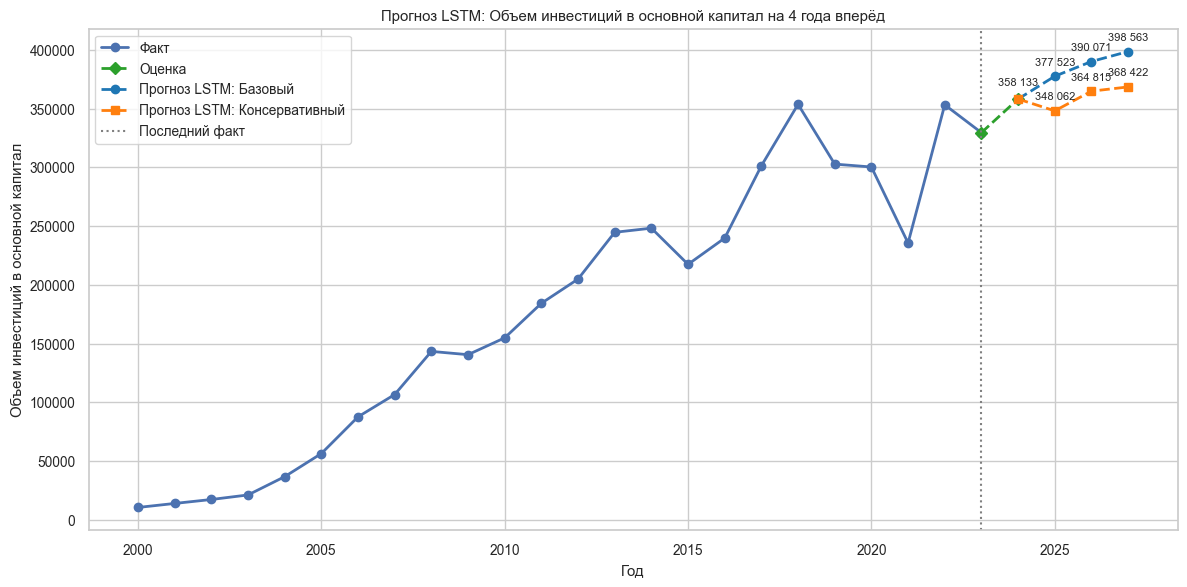

In [56]:
actual_plot_df = model_df[[YEAR_COLUMN, TARGET_COLUMN]].copy()
bridge_row = actual_plot_df.iloc[[-1]].copy()

plt.figure(figsize=(12, 6))
plt.plot(actual_plot_df[YEAR_COLUMN], actual_plot_df[TARGET_COLUMN], marker='o', linewidth=2, label='Факт')

# --- Оценка ---
estimate_plot = lstm_forecast_df[lstm_forecast_df['scenario'] == 'Оценка']
estimate_line = pd.concat([
    bridge_row,
    estimate_plot.rename(columns={'forecast_year': YEAR_COLUMN, 'predicted_investment_volume': TARGET_COLUMN})[[YEAR_COLUMN, TARGET_COLUMN]],
], ignore_index=True)

plt.plot(estimate_line[YEAR_COLUMN], estimate_line[TARGET_COLUMN],
         linestyle='--', marker='D', linewidth=2, color='tab:green', label='Оценка')

for _, row in estimate_plot.iterrows():
    plt.annotate(f"{row['predicted_investment_volume']:,.0f}".replace(',', ' '),
                 xy=(row['forecast_year'], row['predicted_investment_volume']),
                 xytext=(0, 10), textcoords='offset points', ha='center', fontsize=8)

# --- Базовый и Консервативный ---
scenario_styles = {
    'Базовый': {'linestyle': '--', 'marker': 'o', 'color': 'tab:blue'},
    'Консервативный': {'linestyle': '--', 'marker': 's', 'color': 'tab:orange'},
}

scenario_bridge = estimate_plot.rename(
    columns={'forecast_year': YEAR_COLUMN, 'predicted_investment_volume': TARGET_COLUMN}
)[[YEAR_COLUMN, TARGET_COLUMN]]

for scenario_name in ['Базовый', 'Консервативный']:
    sdf = lstm_forecast_df[lstm_forecast_df['scenario'] == scenario_name]
    fpdf = sdf.rename(columns={'forecast_year': YEAR_COLUMN, 'predicted_investment_volume': TARGET_COLUMN})[[YEAR_COLUMN, TARGET_COLUMN]]
    fline = pd.concat([scenario_bridge, fpdf], ignore_index=True)
    style = scenario_styles[scenario_name]

    plt.plot(fline[YEAR_COLUMN], fline[TARGET_COLUMN], linewidth=2,
             label=f'Прогноз LSTM: {scenario_name}', **style)

    for _, row in fpdf.iterrows():
        plt.annotate(f"{row[TARGET_COLUMN]:,.0f}".replace(',', ' '),
                     xy=(row[YEAR_COLUMN], row[TARGET_COLUMN]),
                     xytext=(0, 8), textcoords='offset points', ha='center', fontsize=8)

plt.axvline(latest_fact_year, color='gray', linestyle=':', label='Последний факт')
plt.title(f'Прогноз LSTM: {TARGET_COLUMN} на {FORECAST_HORIZON} года вперёд')
plt.xlabel('Год')
plt.ylabel(TARGET_COLUMN)
plt.legend()
plt.tight_layout()
plt.show()